# AML Football Evaluation Notebook (SerieA)

#### This notebook contains evaluation results of SerieA model goals prediction. The aim is to understand what the machine learning model focuses on to make prediction and evaluate it accuracy in doing so.

#### We made sure the same hyperparameters that was used in this evaluation results were used in the production model.

#### evaluation was carried out on the last ten percent of total matches played by each team on the dataset.

#### Training and model achitecture technique on the model will remain private.

In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
seriea_path = os.getenv(r"SERIEA")

seriea = pd.read_parquet(seriea_path)

In [6]:
seriea.head()

,Date,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,Pred_HomeGoals,Pred_AwayGoals,Home_Pred,Away_Pred,Home_Error,Away_Error
0,2026-01-16,Atalanta,Pisa,0,1,1,1.676338,0.767408,2,1,-1,0
1,2026-01-25,Atalanta,Parma,1,4,0,1.989430,0.657081,2,1,2,-1
2,2026-02-01,Atalanta,Como,0,0,0,1.292457,1.830215,1,2,-1,-2
3,2026-02-09,Atalanta,Cremonese,1,2,1,1.934363,0.704700,2,1,0,0
4,2026-02-14,Atalanta,Lazio,0,2,0,1.793865,0.970890,2,1,0,-1


In [7]:
valid = seriea.dropna(subset=["Pred_HomeGoals", "Pred_AwayGoals"])

# Compute MAE
home_mae = mean_absolute_error(valid["GoalsFor"], valid["Pred_HomeGoals"])
away_mae = mean_absolute_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"])

# Compute RMSE
home_rmse = np.sqrt(mean_squared_error(valid["GoalsFor"], valid["Pred_HomeGoals"]))
away_rmse = np.sqrt(mean_squared_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"]))

# Print neatly
print("Model Evaluation Metrics (per match):")
print("-------------------------------------")
print(f"Home Goals -> MAE: {home_mae:.2f}, RMSE: {home_rmse:.2f}")
print(f"Away Goals -> MAE: {away_mae:.2f}, RMSE: {away_rmse:.2f}")
print("\nNotes:")
print("- MAE shows the typical error per match (average goals off).")
print("- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.")

Model Evaluation Metrics (per match):
-------------------------------------
Home Goals -> MAE: 0.90, RMSE: 1.10
Away Goals -> MAE: 0.91, RMSE: 1.12

Notes:
- MAE shows the typical error per match (average goals off).
- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.


In [8]:
seriea.rename(columns={"Pred_HomeGoals": "RawPred_Home"}, inplace=True)
seriea.rename(columns={"Pred_AwayGoals": "RawPred_Away"}, inplace=True)

In [9]:
seriea["Pred_home"] = seriea["RawPred_Home"].round().astype(int)
seriea["Pred_away"] = seriea["RawPred_Away"].round().astype(int)

In [10]:
seriea["Actual_Outcome"] = np.where(seriea["GoalsFor"] > seriea["GoalsAgainst"], "W",
                                    np.where(seriea["GoalsFor"] < seriea["GoalsAgainst"], "L", "D"))

seriea["Predicted_Outcome"] = np.where(seriea["Pred_home"] > seriea["Pred_away"], "W",
                                    np.where(seriea["Pred_home"] < seriea["Pred_away"], "L", "D"))

In [11]:
accuracy = accuracy_score(seriea["Actual_Outcome"], seriea["Predicted_Outcome"])
accuracy

0.4857142857142857

In [12]:
clss_report = classification_report(seriea["Actual_Outcome"].values, seriea["Predicted_Outcome"].values)
print(clss_report)

              precision    recall  f1-score   support

           D       0.32      0.51      0.39        71
           L       0.62      0.46      0.53       112
           W       0.58      0.51      0.54        97

    accuracy                           0.49       280
   macro avg       0.51      0.49      0.49       280
weighted avg       0.53      0.49      0.50       280



In [13]:
seriea["Home_Error"] = seriea["GoalsFor"] - seriea["Pred_home"]
seriea["Away_Error"] = seriea["GoalsAgainst"] - seriea["Pred_away"]

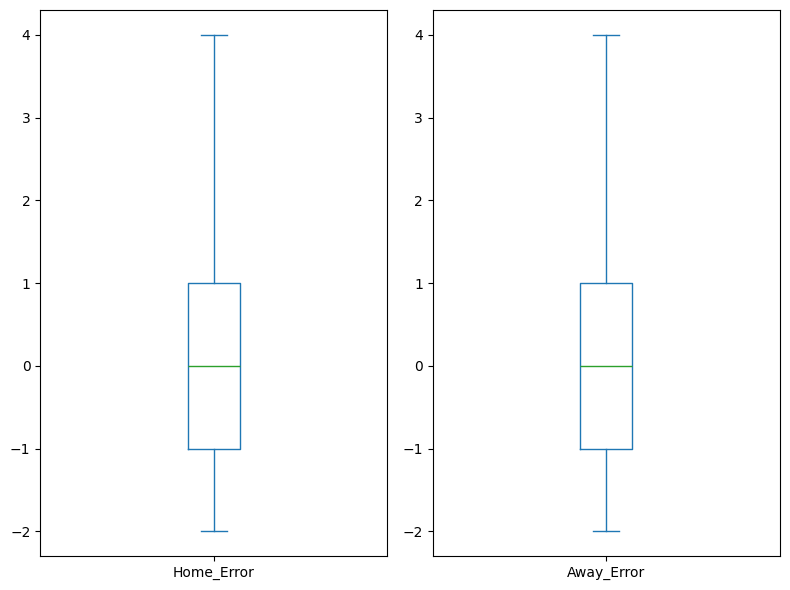

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

seriea["Home_Error"].plot.box(vert=True, ax=axes[0])
seriea["Away_Error"].plot.box(vert=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [15]:
seriea["Home_Error"].value_counts()

Home_Error
-1    97
 0    86
 1    51
 2    23
-2    17
 3     5
 4     1
Name: count, dtype: int64

In [16]:
seriea["Away_Error"].value_counts()

Away_Error
-1    88
 0    85
 1    60
 2    28
-2    11
 3     7
 4     1
Name: count, dtype: int64

In [17]:
count = seriea["Home_Error"].isin([0, 1, -1]).sum()
print(count/len(seriea))

0.8357142857142857


In [18]:
count = seriea["Away_Error"].isin([0, 1, -1]).sum()
print(count/len(seriea))

0.8321428571428572


In [19]:
seriea["Team"].value_counts()

Team
Atalanta       14
Bologna        14
Fiorentina     14
Inter          14
Juventus       14
Lazio          14
Milan          14
Napoli         14
Roma           14
Torino         14
Udinese        14
Verona         14
Cagliari       12
Genoa          12
Sassuolo       12
Empoli          8
Lecce           8
Parma           8
Sampdoria       8
Spezia          8
Monza           6
Salernitana     6
Benevento       4
Como            4
Cremonese       4
Crotone         4
Venezia         4
Frosinone       2
Pisa            2
Name: count, dtype: int64

In [20]:
def ext_mode(df):
    """
    This code extract the maximum value the model have been wrong by for the team
    """
    maxi = {}

    for team, group in df.groupby("Team"):
        max_value = group["Home_Error"].max()
        maxi[team] = max_value
        
    return maxi

In [21]:
maxi = ext_mode(seriea)

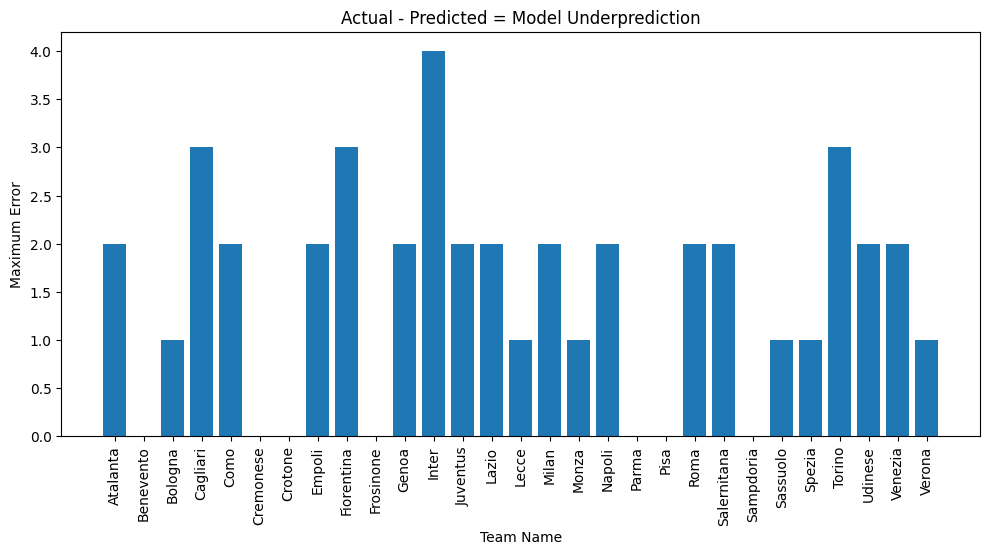

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(maxi.keys(), maxi.values())
plt.xlabel("Team Name")
plt.ylabel("Maximum Error")
plt.title("Actual - Predicted = Model Underprediction")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [23]:
#Checking patterns of teams that performed more than expected have in similar based on the plots above 3, 4 and 5

outliers = seriea[seriea["Home_Error"].isin([3, 4, 5, 6])]
outliers

,Date,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,RawPred_Home,RawPred_Away,Home_Pred,Away_Pred,Home_Error,Away_Error,Pred_home,Pred_away,Actual_Outcome,Predicted_Outcome
32,2026-01-31,Cagliari,Verona,1,4,0,1.375431,0.716905,1,1,3,-1,1,1,W,D
72,2026-03-16,Fiorentina,Cremonese,0,4,1,1.175745,0.442098,1,0,3,1,1,0,W,W
93,2026-01-23,Inter,Pisa,1,6,2,2.082760,0.115733,2,0,4,2,2,0,W,W
95,2026-02-08,Inter,Sassuolo,0,5,0,2.091439,0.152191,2,0,3,0,2,0,W,W
102,2026-04-05,Inter,Roma,1,5,2,2.224514,0.520836,2,1,3,1,2,1,W,W
242,2026-03-13,Torino,Parma,1,4,1,1.403403,1.225017,1,1,3,0,1,1,W,D


In [24]:
seriea["Match_Error"] = np.abs(seriea["Home_Error"]) + np.abs(seriea["Away_Error"])
seriea["Match_Error"].value_counts()

Match_Error
2    101
1     86
3     41
0     31
4     19
6      1
5      1
Name: count, dtype: int64

In [25]:
count = seriea["Match_Error"].isin([0, 1, 2, 3]).sum()
print(f"Total accuracy when actual total match goals - predicted total match goals is 3 or less is {round(count/len(seriea) * 100, 1)}%")

Total accuracy when actual total match goals - predicted total match goals is 3 or less is 92.5%


## There is a clear correlation with home team and overscoring what the model predicted. Away team underprediction occured twice in this outlier events with juventus and fiorentina, remaining was home

# SUMMARY

## The model performs badly in 3 way scenerio (i.e home/draw/away) having 47% accuracy which isn't reliable, but performs very good in recognizing possible goals that can be scored, taking into consideration; exact goal, +1, and -1 goals scenerio, with an average accuracy of 86%.

## Outliers events are 3 and 4 goals underprediction. In order to put it out to production, we will focus on managing the risks associated with these errors.